In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("metabric_patient_level.csv")

print(df.shape)


(2509, 137)


In [2]:
for col in df.columns:
    print(f"{col}: {df[col].unique()[:10]}")

PATIENT_ID: <StringArray>
['MB-0000', 'MB-0002', 'MB-0005', 'MB-0006', 'MB-0008', 'MB-0010', 'MB-0014',
 'MB-0020', 'MB-0022', 'MB-0025']
Length: 10, dtype: str
LYMPH_NODES_EXAMINED_POSITIVE: [10.  0.  1.  3.  8. nan 11. 24.  4. 16.]
NPI: [6.044 4.02  4.03  4.05  6.08  4.062 6.13  4.058 6.68  5.032]
CELLULARITY: <StringArray>
[nan, 'High', 'Moderate', 'Low']
Length: 4, dtype: str
CHEMOTHERAPY: <StringArray>
['NO', 'YES', nan]
Length: 3, dtype: str
COHORT: [ 1.  2.  3.  5.  4.  9.  7.  6. nan  8.]
ER_IHC: <StringArray>
['Positve', 'Negative', nan]
Length: 3, dtype: str
HER2_SNP6: <StringArray>
['NEUTRAL', 'LOSS', nan, 'GAIN', 'UNDEF']
Length: 5, dtype: str
HORMONE_THERAPY: <StringArray>
['YES', 'NO', nan]
Length: 3, dtype: str
INFERRED_MENOPAUSAL_STATE: <StringArray>
['Post', 'Pre', nan]
Length: 3, dtype: str
SEX: <StringArray>
['Female']
Length: 1, dtype: str
INTCLUST: <StringArray>
['4ER+', '3', '9', '7', '4ER-', nan, '5', '8', '10', '1']
Length: 10, dtype: str
AGE_AT_DIAGNOSIS: [75.6

In [3]:
# Identify gene columns
gene_cols = [col for col in df.columns if col not in [
    'PATIENT_ID', 'LYMPH_NODES_EXAMINED_POSITIVE', 'NPI', 'CELLULARITY',
    'CHEMOTHERAPY', 'COHORT', 'ER_IHC', 'HER2_SNP6', 'HORMONE_THERAPY',
    'INFERRED_MENOPAUSAL_STATE', 'SEX', 'INTCLUST', 'AGE_AT_DIAGNOSIS',
    'OS_MONTHS', 'OS_STATUS', 'CLAUDIN_SUBTYPE', 'THREEGENE', 'VITAL_STATUS',
    'LATERALITY', 'RADIO_THERAPY', 'HISTOLOGICAL_SUBTYPE', 'BREAST_SURGERY',
    'RFS_MONTHS', 'RFS_STATUS', 'SAMPLE_ID', 'CANCER_TYPE', 'CANCER_TYPE_DETAILED',
    'ER_STATUS', 'HER2_STATUS', 'GRADE', 'ONCOTREE_CODE', 'PR_STATUS',
    'SAMPLE_TYPE', 'TUMOR_SIZE', 'TUMOR_STAGE', 'TMB_NONSYNONYMOUS', 'recurred'
]]

print(f"Gene columns found: {len(gene_cols)}")
print(f"NaN in gene cols before fill: {df[gene_cols].isnull().sum().sum()}")

df[gene_cols] = df[gene_cols].fillna(0)

print(f"NaN in gene cols after fill: {df[gene_cols].isnull().sum().sum()}")

Gene columns found: 100
NaN in gene cols before fill: 14900
NaN in gene cols after fill: 0


In [4]:
df["recurred"].value_counts(normalize=True) * 100

recurred
0.0    59.726688
1.0    40.273312
Name: proportion, dtype: float64

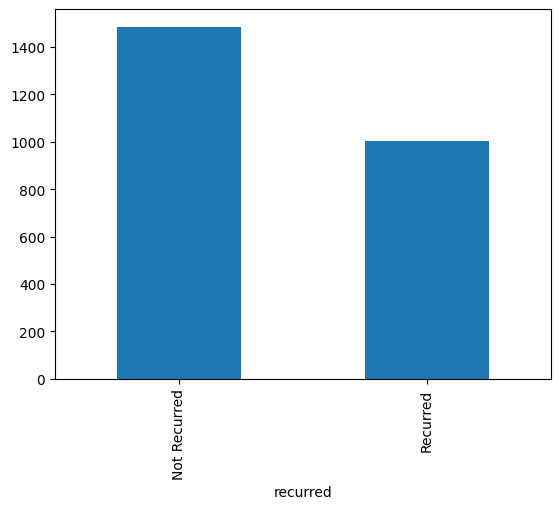

In [5]:
df["recurred"].value_counts().rename({0: "Not Recurred", 1: "Recurred"}).plot(kind="bar")
plt.show()

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
(missing / len(df) * 100).round(1)

THREEGENE                        29.7
TUMOR_STAGE                      28.7
LATERALITY                       25.5
CELLULARITY                      23.6
BREAST_SURGERY                   22.1
INTCLUST                         21.1
HER2_STATUS                      21.1
RADIO_THERAPY                    21.1
VITAL_STATUS                     21.1
CHEMOTHERAPY                     21.1
INFERRED_MENOPAUSAL_STATE        21.1
HORMONE_THERAPY                  21.1
HER2_SNP6                        21.1
PR_STATUS                        21.1
CLAUDIN_SUBTYPE                  21.1
OS_STATUS                        21.0
OS_MONTHS                        21.0
LYMPH_NODES_EXAMINED_POSITIVE    10.6
NPI                               8.8
TUMOR_SIZE                        5.9
HISTOLOGICAL_SUBTYPE              5.4
GRADE                             4.8
RFS_MONTHS                        4.8
ER_IHC                            3.3
ER_STATUS                         1.6
RFS_STATUS                        0.8
recurred    

In [7]:
df["ER_IHC"] = df["ER_IHC"].replace("Positve", "Positive")
df["HER2_SNP6"] = df["HER2_SNP6"].replace("UNDEF", pd.NA)
df["CLAUDIN_SUBTYPE"] = df["CLAUDIN_SUBTYPE"].replace("NC", pd.NA)

In [8]:
cat_cols = df.select_dtypes(include="str").columns


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
(missing / len(df) * 100).round(1)

THREEGENE                        29.7
TUMOR_STAGE                      28.7
LATERALITY                       25.5
CELLULARITY                      23.6
BREAST_SURGERY                   22.1
CLAUDIN_SUBTYPE                  21.3
HER2_SNP6                        21.3
VITAL_STATUS                     21.1
HER2_STATUS                      21.1
INTCLUST                         21.1
CHEMOTHERAPY                     21.1
HORMONE_THERAPY                  21.1
INFERRED_MENOPAUSAL_STATE        21.1
PR_STATUS                        21.1
RADIO_THERAPY                    21.1
OS_STATUS                        21.0
OS_MONTHS                        21.0
LYMPH_NODES_EXAMINED_POSITIVE    10.6
NPI                               8.8
TUMOR_SIZE                        5.9
HISTOLOGICAL_SUBTYPE              5.4
GRADE                             4.8
RFS_MONTHS                        4.8
ER_IHC                            3.3
ER_STATUS                         1.6
RFS_STATUS                        0.8
recurred    

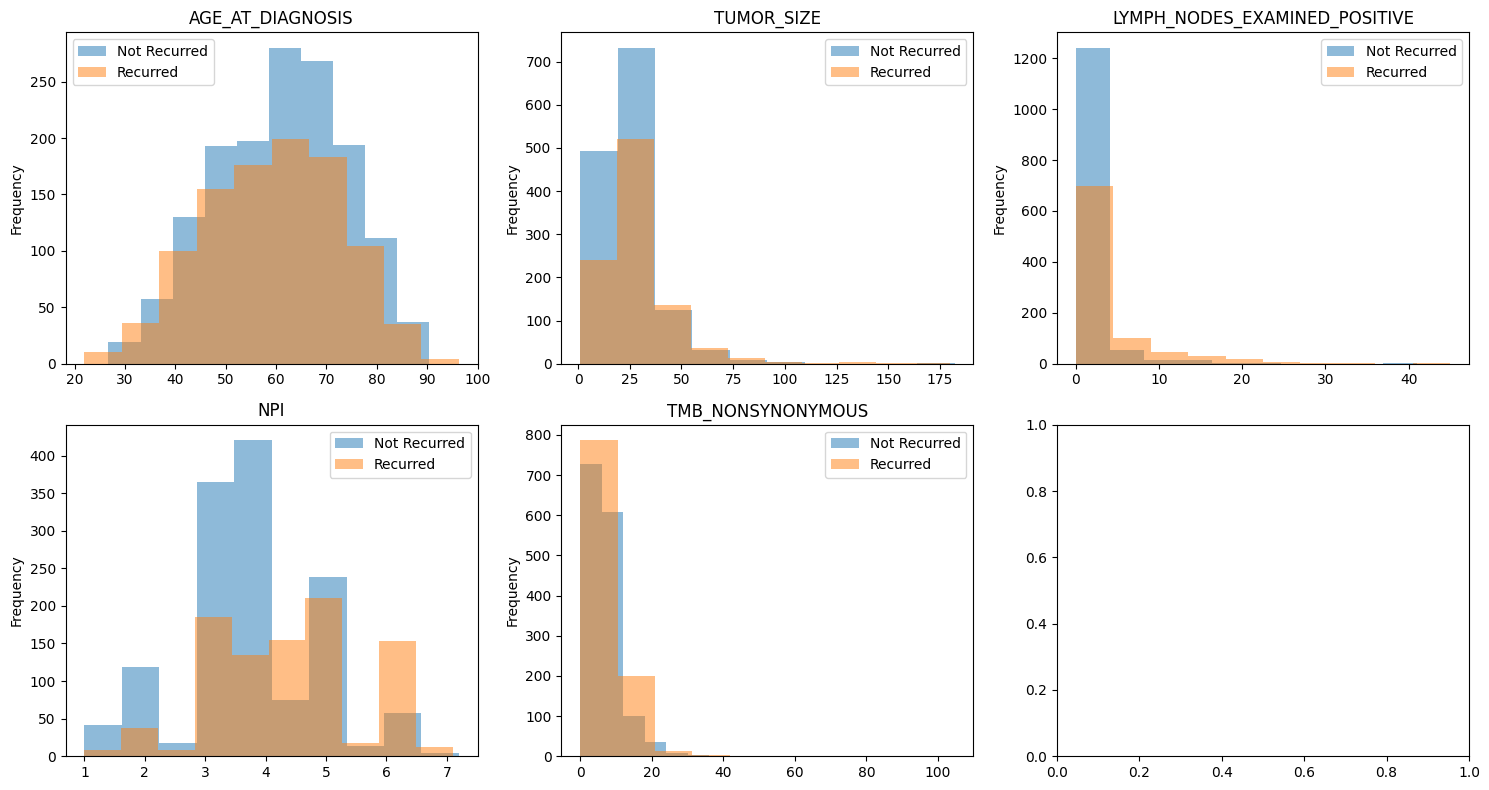

In [10]:
num_cols = ["AGE_AT_DIAGNOSIS", "TUMOR_SIZE", "LYMPH_NODES_EXAMINED_POSITIVE", "NPI", "TMB_NONSYNONYMOUS"]

df_labeled = df.dropna(subset=["recurred"])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df_labeled.groupby("recurred")[col].plot(kind="hist", alpha=0.5, legend=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend(["Not Recurred", "Recurred"])

plt.tight_layout()
plt.show()


Clinical features vs recurrence distributions explanation :

AGE_AT_DIAGNOSIS : distributions heavily overlap, age alone is not a strong separator



TUMOR_SIZE : recurred patients tend to have slightly larger tumors, but overlap is high



LYMPH_NODES_EXAMINED_POSITIVE :  most patients have 0 positive nodes, recurred patients have slightly more



NPI : recurred patients shift toward higher NPI values (4–6 range)



TMB_NONSYNONYMOUS : distributions almost identical, mutation burden alone doesn't separate well



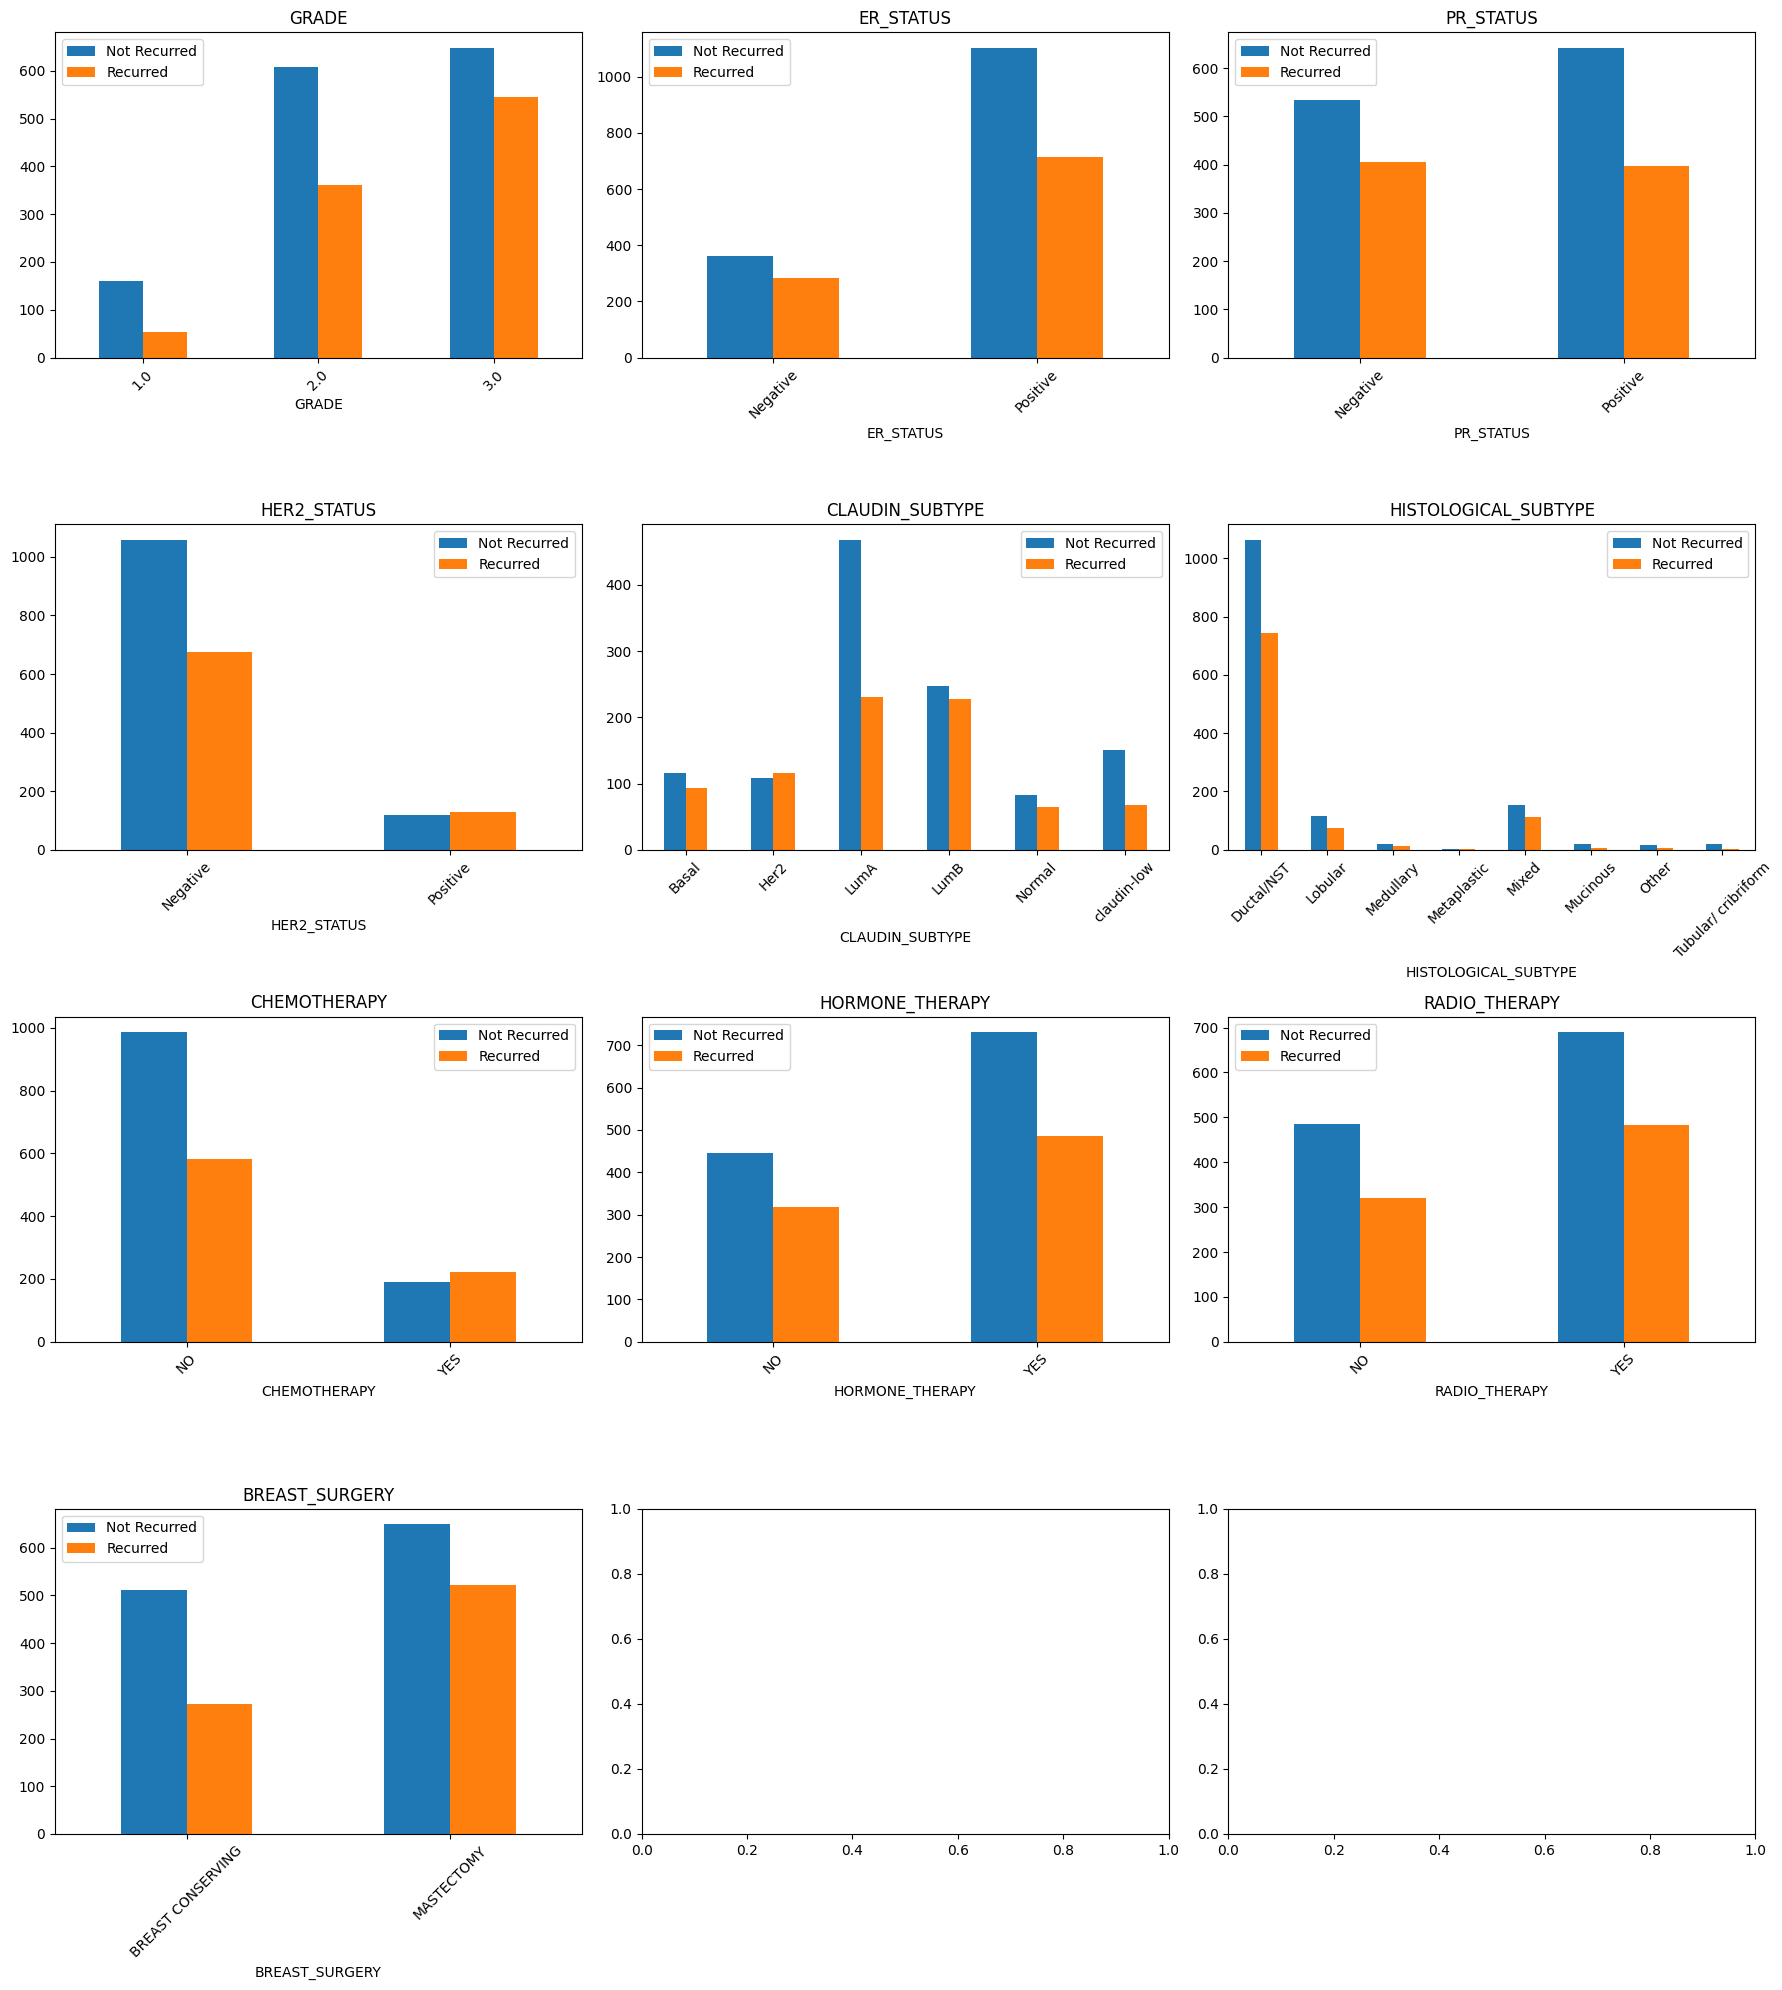

In [11]:
cat_features = ["GRADE", "ER_STATUS", "PR_STATUS", "HER2_STATUS", 
                "CLAUDIN_SUBTYPE", "HISTOLOGICAL_SUBTYPE", "CHEMOTHERAPY", 
                "HORMONE_THERAPY", "RADIO_THERAPY", "BREAST_SURGERY"]

df_labeled = df.dropna(subset=["recurred"])

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    df_labeled.groupby([col, "recurred"]).size().unstack().plot(kind="bar", ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend(["Not Recurred", "Recurred"])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Categorical columns vs recurrence distributions explanation :

GRADE : clear signal, Grade 3 has much higher recurrence rate, Grade 1 barely recurs 

ER_STATUS : ER Negative patients recur proportionally more than ER Positive 

PR_STATUS : similar to ER, PR Negative recurs more 

HER2_STATUS : HER2 Positive patients recur at a higher rate relative to their group size 

CLAUDIN_SUBTYPE : strong signal, LumA barely recurs, Basal and claudin-low recur heavily 

HISTOLOGICAL_SUBTYPE : Ductal/NST dominates, not much separation across subtypes 

Treatment features (chemotherapy, hormone therapy, radiotherapy, surgery type) show higher recurrence rates in treated groups because  doctors give aggressive treatment to high-risk patients


In [13]:
gene_cols = [col for col in df.columns if col not in df.select_dtypes(include="str").columns 
             and col not in ["recurred", "GRADE", "TUMOR_SIZE", "TUMOR_STAGE", 
                             "LYMPH_NODES_EXAMINED_POSITIVE", "NPI", "TMB_NONSYNONYMOUS",
                             "AGE_AT_DIAGNOSIS", "OS_MONTHS", "RFS_MONTHS", "COHORT"]]
df_labeled = df.dropna(subset=["recurred"])

gene_recurrence = {}
for gene in gene_cols:
    mutated = df_labeled[df_labeled[gene] == 1]["recurred"].mean()
    not_mutated = df_labeled[df_labeled[gene] == 0]["recurred"].mean()
    gene_recurrence[gene] = {"mutated": mutated, "not_mutated": not_mutated}

gene_df = pd.DataFrame(gene_recurrence).T
gene_df["difference"] = gene_df["mutated"] - gene_df["not_mutated"]
gene_df = gene_df.sort_values("difference", ascending=False)

print(gene_df.head(10))
print("\n")
print(gene_df.tail(10))

          mutated  not_mutated  difference
MYO3A    0.567901     0.397175    0.170726
THSD7A   0.564706     0.397004    0.167702
COL22A1  0.511450     0.396691    0.114760
ARID1A   0.503356     0.396323    0.107032
MYH9     0.504348     0.397809    0.106539
TP53     0.466357     0.369004    0.097354
PALLD    0.488889     0.401146    0.087743
ATR      0.477876     0.399158    0.078718
MYO1A    0.478873     0.400496    0.078377
STAB2    0.476923     0.398643    0.078280


         mutated  not_mutated  difference
PIK3R1  0.333333     0.404713   -0.071379
ASXL1   0.333333     0.404801   -0.071468
RUNX1   0.329670     0.405507   -0.075837
CHD1    0.327869     0.404615   -0.076746
LIFR    0.327273     0.404439   -0.077166
FAM20C  0.325581     0.404090   -0.078509
GATA3   0.327526     0.412540   -0.085014
CTCF    0.300000     0.405707   -0.105707
EGFR    0.294118     0.405785   -0.111667
CBFB    0.281818     0.408326   -0.126508


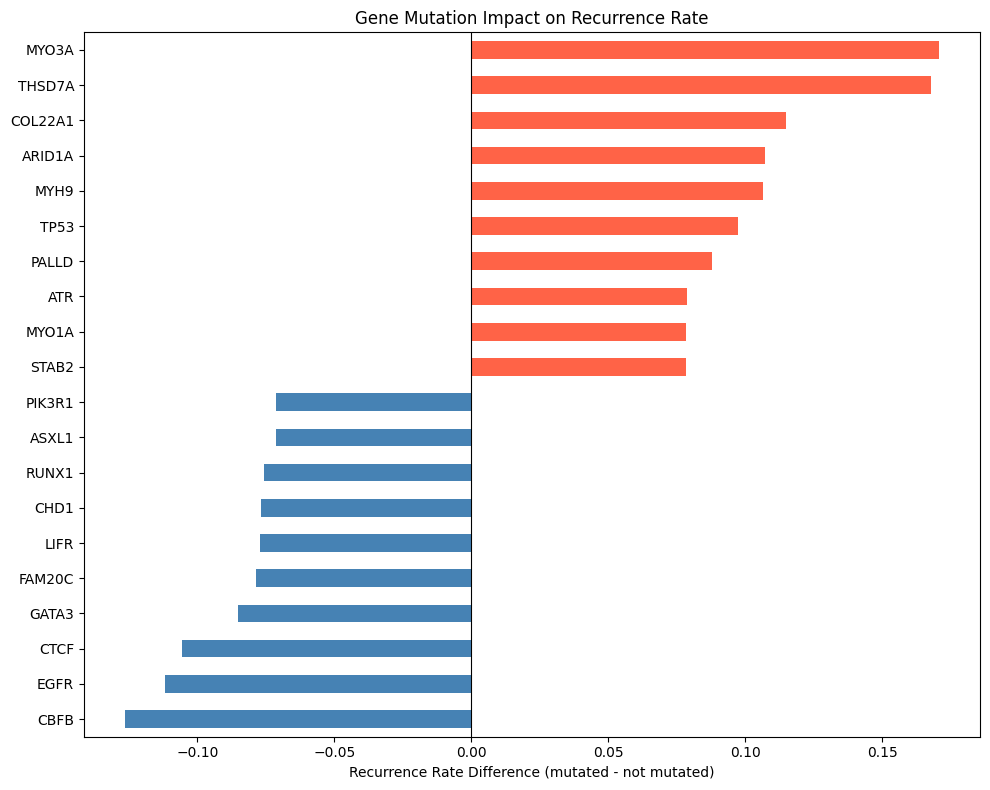

In [15]:
top_bottom["difference"].sort_values().plot(kind="barh", figsize=(10, 8),
                               color=["steelblue" if x < 0 else "tomato" 
                                      for x in top_bottom["difference"].sort_values()])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Gene Mutation Impact on Recurrence Rate")
plt.xlabel("Recurrence Rate Difference (mutated - not mutated)")
plt.tight_layout()
plt.show()

To understand which gene mutations are associated with breast cancer recurrence, we calculated the difference in recurrence rate between patients who had a mutation in a given gene and those who did not. A positive value (red) means that patients with that mutation recurred more often, while a negative value (blue) means they recurred less often. The strongest positive signals come from MYO3A, THSD7A, and TP53 ,patients with these mutations had up to 17% higher recurrence rates.


On the other hand, mutations in CBFB, EGFR, and GATA3 were associated with lower recurrence rates

 It is important to note that no single gene perfectly predicts recurrence, the differences are modest, and the model will need to combine multiple genes alongside clinical features to make accurate predictions

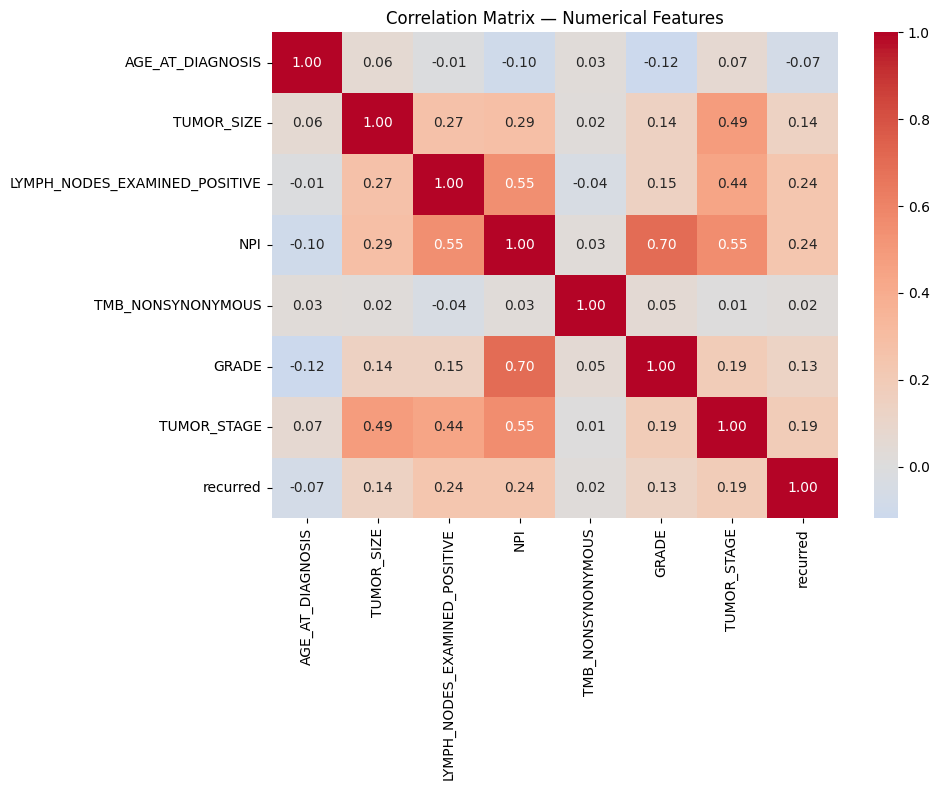

In [16]:
num_cols = ["AGE_AT_DIAGNOSIS", "TUMOR_SIZE", "LYMPH_NODES_EXAMINED_POSITIVE", 
            "NPI", "TMB_NONSYNONYMOUS", "GRADE", "TUMOR_STAGE", "recurred"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numerical Features")
plt.tight_layout()
plt.show()

NPI is highly correlated with GRADE, LYMPH_NODES and TUMOR_STAGE because it's a composite score built from them. Keeping all of them together in the model may cause redundancy

In [17]:
from collections import Counter

labeled = df.dropna(subset=["recurred"])
counter = Counter(labeled["recurred"])

ratio = counter[0.0] / counter[1.0]
print(f"Not Recurred: {counter[0.0]}")
print(f"Recurred:     {counter[1.0]}")
print(f"Ratio:        {ratio:.2f}")

Not Recurred: 1486
Recurred:     1002
Ratio:        1.48


In [18]:
df.to_csv("metabric_after_eda.csv", index=False)
print("Saved!")
print(f"Shape: {df.shape}")

Saved!
Shape: (2509, 137)
